In [ ]:
# https://github.com/akd6203/brain-tumor-detection

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from dotenv import find_dotenv, load_dotenv
import cv2

load_dotenv(find_dotenv(usecwd=True))

DATA_ROOT = Path(os.getenv(
    "BRAIN_TUMOR_DATA_DIR",
    os.getenv("DATA_ROOT", Path.cwd() / "data" / "raw"),
))
TRAINING_DIR = Path(os.getenv("TRAINING_DATA_DIR", DATA_ROOT / "Training"))
TESTING_DIR = Path(os.getenv("TESTING_DATA_DIR", DATA_ROOT / "Testing"))


In [4]:
training_dir = TRAINING_DIR
testing_dir = TESTING_DIR
classes = {"no_tumor": 0, "glioma_tumor": 1, "meningioma_tumor":2, "pituitary_tumor": 3}

In [5]:
# Load and count the data

def folder_counts(root):
    return {cls: len(os.listdir(os.path.join(root, cls)))
            for cls in sorted(os.listdir(root))}

print("Training:", folder_counts(training_dir))
print("Testing :", folder_counts(testing_dir))

Training: {'glioma_tumor': 826, 'meningioma_tumor': 822, 'no_tumor': 395, 'pituitary_tumor': 827}
Testing : {'glioma_tumor': 100, 'meningioma_tumor': 115, 'no_tumor': 105, 'pituitary_tumor': 74}


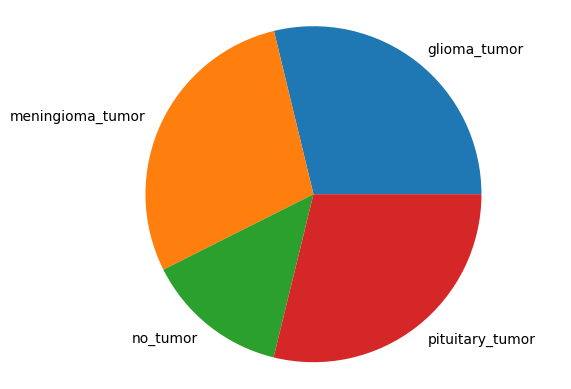

In [ ]:
labels = []
sizes = []

for x, y in folder_counts(training_dir).items():
    labels.append(x)
    sizes.append(y)

# Plot
plt.pie(sizes, labels=labels)

plt.axis('equal')
plt.title("Training Data Distribution")
plt.show()

In [ ]:
labels = []
sizes = []

for x, y in folder_counts(testing_dir).items():
    labels.append(x)
    sizes.append(y)

# Plot
plt.pie(sizes, labels=labels)

plt.axis('equal')
plt.title("Testing Data Distribution")
plt.show()

In [6]:
def load_data(training_dir, classes):
    
    X = [] # list of images
    Y = [] # classes associated to the training images 

    training_dir = training_dir
    classes = classes

    for cls in classes: # loops through the defined classes (no_tumor / pituitary_tumor)
        pth = os.path.join(training_dir, cls)
        print(pth)
        for j in os.listdir(pth):
            img = cv2.imread(os.path.join(pth, j), 0) # read image 
            img = cv2.resize(img, (200, 200)) # resize
            X.append(img) # append image
            Y.append(classes[cls]) # append class

    return X,Y
X, Y = load_data(training_dir, classes)

/Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/data/raw/Training/no_tumor
/Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/data/raw/Training/glioma_tumor
/Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/data/raw/Training/meningioma_tumor
/Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/data/raw/Training/pituitary_tumor


In [7]:
# turn images into numpy arrays
X = np.array(X)
Y = np.array(Y)

In [8]:
# this line of code reshapes each image into a 1D vector 
# (n, 200, 200) --> (n, 200*200) = (n, 40000)
X_updated = X.reshape(len(X), -1)

## General Data Inspection

In [9]:
np.unique(X)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [10]:
np.unique(Y)

array([0, 1, 2, 3])

In [11]:
X.shape, X_updated.shape, Y.shape

((2870, 200, 200), (2870, 40000), (2870,))

## Data Visualization

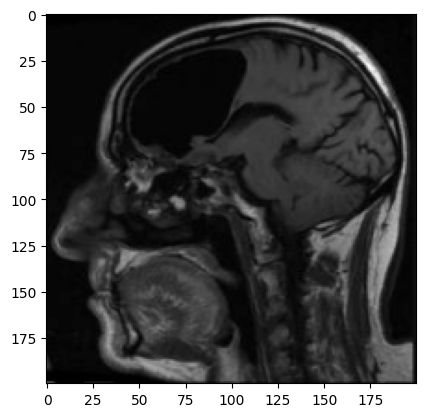

In [12]:
plt.imshow(X[0], cmap="gray");

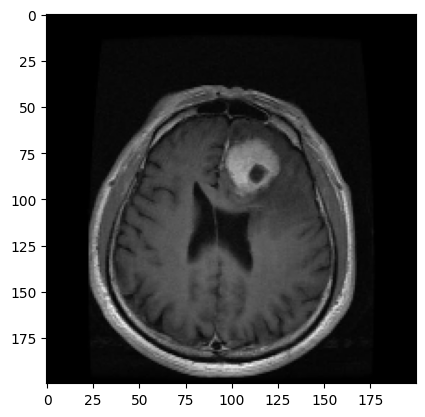

In [13]:
plt.imshow(X[1221], cmap="gray");